# Traffic Sign Detection with RF-DETR

## Imports

In [1]:
import shutil
import json
from pathlib import Path

## Setting Directory Locations

Note: the code below was originally used prior to the GitHub setup. It was intended to be run using the output generated from LS2COCO.ipynb. If this format is used, rather than the GitHub one, skip the code block labelled "GitHub Format".

In [ ]:
DATASET_ROOT_DIR = Path("Data")
GITHUB_REPO_DIR = False

In [ ]:
# GITHUB FORMAT
GITHUB_REPO_DIR = True
DATASET_ROOT_DIR = Path("Dataset/TiffaneyPsaila")
IMG_ROOT_DIR = Path("Dataset/images")

In [ ]:
# for github format
def convert_coco_to_rf_detr_g(src_ann_dir,      # directory containing train.json / val.json / test.json
                            src_img_dir,      # bulk directory containing all images
                            dst_dataset_dir,  # output RF-DETR dataset dir
                            rewrite_file_name=True):

    src_ann_dir = Path(src_ann_dir)
    src_img_dir = Path(src_img_dir)
    dst = Path(dst_dataset_dir)

    splits = {
        "train": "train",
        "val": "valid",
        "test": "test",
    }

    # Build a quick lookup map from basename -> full path for bulk images
    # (Assumes basenames are unique. If not, you must match by relative path.)
    img_index = {}
    for p in src_img_dir.rglob("*"):
        if p.is_file():
            img_index[p.name] = p

    for coco_split, rf_split in splits.items():
        print(f"Processing {coco_split} → {rf_split}")

        src_ann_file = src_ann_dir / f"{coco_split}.json"
        if not src_ann_file.exists():
            raise FileNotFoundError(f"Missing annotation file: {src_ann_file}")

        dst_split_dir = dst / rf_split
        dst_split_dir.mkdir(parents=True, exist_ok=True)

        # Load annotations so we can copy only referenced images (and optionally rewrite file_name)
        with src_ann_file.open("r", encoding="utf-8") as f:
            coco = json.load(f)

        copied = 0
        missing = 0
        seen = set()

        for img in coco.get("images", []):
            file_name = img.get("file_name", "")
            base = Path(file_name).name  # handles 'a/b/c.jpg' -> 'c.jpg'

            # Find matching image in bulk dir
            src_img_path = img_index.get(base)
            if src_img_path is None or not src_img_path.exists():
                missing += 1
                # Print a few misses to help debug, but don't spam
                if missing <= 10:
                    print(f"  [MISSING] {file_name} (looked for basename: {base})")
                continue

            dst_img_path = dst_split_dir / base
            if dst_img_path not in seen:
                shutil.copy2(src_img_path, dst_img_path)
                seen.add(dst_img_path)
                copied += 1

            if rewrite_file_name:
                img["file_name"] = base  # RF-DETR-style: image is in same folder as _annotations.json

        # Write RF-DETR expected annotation filename
        dst_ann_file = dst_split_dir / "_annotations.json"
        with dst_ann_file.open("w", encoding="utf-8") as f:
            json.dump(coco, f, ensure_ascii=False)

        print(f"  Copied annotations and {copied} images")
        if missing:
            print(f"  WARNING: {missing} images referenced in JSON were not found in bulk dir")

    print("\nConversion complete.")

if GITHUB_REPO_DIR:
    convert_coco_to_rf_detr_g(DATASET_ROOT_DIR / "COCO-based_COCO", IMG_ROOT_DIR, DATASET_ROOT_DIR / "coco_set" / "coco_based_coco")

## Arranging Subdirectory Format

In [ ]:
def convert_coco_to_rf_detr(src_dataset_dir, dst_dataset_dir):
    src = Path(src_dataset_dir)
    dst = Path(dst_dataset_dir)

    splits = {
        "train": "train",
        "val": "valid",   # RF-DETR expects "valid"
        "test": "test"
    }

    for coco_split, rf_split in splits.items():
        print(f"Processing {coco_split} → {rf_split}")

        src_img_dir = src / "images" / coco_split
        src_ann_file = src / "annotations" / f"{coco_split}.json"

        dst_split_dir = dst / rf_split
        dst_split_dir.mkdir(parents=True, exist_ok=True)

        # copy annotation file
        dst_ann_file = dst_split_dir / "_annotations.json"
        shutil.copy2(src_ann_file, dst_ann_file)

        # copy all images
        for img_path in src_img_dir.iterdir():
            shutil.copy2(img_path, dst_split_dir / img_path.name)

        print(f"  Copied annotations and {len(list(src_img_dir.iterdir()))} files")

    print("\nConversion complete.")


if GITHUB_REPO_DIR == False:
    convert_coco_to_rf_detr(DATASET_ROOT_DIR / "COCO-based_COCO", DATASET_ROOT_DIR / "coco_set" / "coco_based_coco")

Processing train → train
  Copied annotations and 467 files
Processing val → valid
  Copied annotations and 89 files
Processing test → test
  Copied annotations and 89 files

Conversion complete.


## Setting Supercategories
note: these were required for RF-DETR to function

In [ ]:
annotation_paths = [DATASET_ROOT_DIR / "coco_set" / "coco_based_coco" / "test" / "_annotations.json",
                     DATASET_ROOT_DIR / "coco_set" / "coco_based_coco" / "train" / "_annotations.json",
                     DATASET_ROOT_DIR / "coco_set" / "coco_based_coco" / "valid" / "_annotations.json"]

image_paths = [DATASET_ROOT_DIR / "coco_set" / "coco_based_coco" / "test",
               DATASET_ROOT_DIR / "coco_set" / "coco_based_coco" / "train",
               DATASET_ROOT_DIR / "coco_set" / "coco_based_coco" / "valid"]

In [5]:
for path in annotation_paths:
    coco_path = Path(path)

    with open(coco_path, "r") as f:
        data = json.load(f)

    for c in data["categories"]:
        if "supercategory" not in c:
            c["supercategory"] = c["name"]

    with open(coco_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"Fixed categories for {path}")


Fixed categories for coco_set\coco_based_coco\test\_annotations.json
Fixed categories for coco_set\coco_based_coco\train\_annotations.json
Fixed categories for coco_set\coco_based_coco\valid\_annotations.json


## Adjusting Filenames in Annotations to Match Actual Filenames

In [9]:
def renamer(name: str) -> str:
    s = name.replace(" ", "_").replace("(", "_").replace(")", "_").replace("+", "_")
    return s

def build_actual_lookup(image_dirs):
    lookup = {}
    for d in image_dirs:
        for p in d.rglob("*"):
            if p.is_file():
                bn = p.name
                key = renamer(bn)

                # manage collisions
                lookup[key] = bn
    return lookup

if GITHUB_REPO_DIR == False:
    actual_lookup = build_actual_lookup(image_paths)

def patch_coco_file(json_path: Path):
    if not json_path.exists():
        print(f"Skip (missing): {json_path}")
        return

    data = json.loads(json_path.read_text(encoding="utf-8"))
    base_dir = json_path.parent

    fixed = 0
    still_missing = []

    for img in data.get("images", []):
        fn = img.get("file_name")
        if not fn:
            continue

        fn_path = Path(fn)
        prefix = fn_path.parent if str(fn_path.parent) != "." else Path("")
        basename = fn_path.name

        # If it already exists exactly as referenced, keep it
        if (base_dir / fn).exists():
            continue

        # Try direct normalization (assumes renamer applied to original basename)
        normalized = renamer(basename)
        candidate_rel = str(prefix / normalized) if prefix != Path("") else normalized
        if (base_dir / candidate_rel).exists():
            img["file_name"] = candidate_rel
            fixed += 1
            continue

        # Try lookup against actual filenames on disk (handles cases where collapsing differs)
        actual_bn = actual_lookup.get(renamer(basename))
        if actual_bn:
            candidate_rel2 = str(prefix / actual_bn) if prefix != Path("") else actual_bn

            # First try in the same relative subfolder
            if (base_dir / candidate_rel2).exists():
                img["file_name"] = candidate_rel2
                fixed += 1
                continue

            # Fallback: try just the basename in the json folder
            if (base_dir / actual_bn).exists():
                img["file_name"] = actual_bn
                fixed += 1
                continue

        still_missing.append(fn)

    json_path.write_text(json.dumps(data, indent=2), encoding="utf-8")
    print(f"{json_path}: fixed {fixed} filenames")

    if still_missing:
        print("  Still missing (up to 10 shown):")
        for m in still_missing[:10]:
            print("   -", m)

if GITHUB_REPO_DIR == False:
    for js in annotation_paths:
        patch_coco_file(js)


coco_set\coco_based_coco\test\_annotations.json: fixed 0 filenames
coco_set\coco_based_coco\train\_annotations.json: fixed 0 filenames
coco_set\coco_based_coco\valid\_annotations.json: fixed 0 filenames


## Remapping COCO Class IDs to 0...N-1
note: this was also required for RF-DETR to function.

In [ ]:
import json
from pathlib import Path

def remap_coco(in_path, out_path):
    d = json.loads(Path(in_path).read_text(encoding="utf-8"))
    old_ids = [c["id"] for c in d["categories"]]
    id_map = {old:i for i, old in enumerate(sorted(old_ids))}

    for c in d["categories"]:
        c["id"] = id_map[c["id"]]
    for a in d["annotations"]:
        a["category_id"] = id_map[a["category_id"]]

    Path(out_path).write_text(json.dumps(d, indent=2), encoding="utf-8")
    print("wrote", out_path, "mapping:", id_map)

for js in annotation_paths:
    remap_coco(js, js)


wrote coco_set\coco_based_coco\test\_annotations.coco.json mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
wrote coco_set\coco_based_coco\train\_annotations.coco.json mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
wrote coco_set\coco_based_coco\valid\_annotations.coco.json mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}


## Training the Model

In [12]:
from rfdetr.detr import RFDETRBase

In [ ]:
model = RFDETRBase()

model.train(
    dataset_dir=DATASET_ROOT_DIR / r"coco_set\coco_based_coco",
    epochs=100,
    batch_size=4,
    grad_accum_steps=4,
    lr=1e-4,
    output_dir=DATASET_ROOT_DIR / r"runs/rfdetr",
    mixed_precision="fp16",
    tensorboard=True,
    early_stopping=True
)

Loading pretrain weights
TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir F:\programming_stuff\out_rfdetr_long' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=7, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=100, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_fe

Epoch: [0]  [ 0/29]  eta: 0:03:00  lr: 0.000100  class_error: 100.00  loss: 14.4511 (14.4511)  loss_ce: 2.9051 (2.9051)  loss_bbox: 0.3908 (0.3908)  loss_giou: 0.3217 (0.3217)  loss_ce_0: 2.9143 (2.9143)  loss_bbox_0: 0.3869 (0.3869)  loss_giou_0: 0.3351 (0.3351)  loss_ce_1: 2.9351 (2.9351)  loss_bbox_1: 0.3547 (0.3547)  loss_giou_1: 0.3291 (0.3291)  loss_ce_enc: 2.7328 (2.7328)  loss_bbox_enc: 0.4454 (0.4454)  loss_giou_enc: 0.4002 (0.4002)  loss_ce_unscaled: 2.9051 (2.9051)  class_error_unscaled: 100.0000 (100.0000)  loss_bbox_unscaled: 0.0782 (0.0782)  loss_giou_unscaled: 0.1608 (0.1608)  cardinality_error_unscaled: 3853.5000 (3853.5000)  loss_ce_0_unscaled: 2.9143 (2.9143)  loss_bbox_0_unscaled: 0.0774 (0.0774)  loss_giou_0_unscaled: 0.1675 (0.1675)  cardinality_error_0_unscaled: 3737.0000 (3737.0000)  loss_ce_1_unscaled: 2.9351 (2.9351)  loss_bbox_1_unscaled: 0.0709 (0.0709)  loss_giou_1_unscaled: 0.1645 (0.1645)  cardinality_error_1_unscaled: 3833.0000 (3833.0000)  loss_ce_enc_un

## TensorBoard

In [5]:
import tensorboard
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [6]:
%tensorboard --logdir out_rfdetr_long

Reusing TensorBoard on port 6007 (pid 22988), started 3 days, 7:18:58 ago. (Use '!kill 22988' to kill it.)

## Loading Best Model

In [ ]:
model = RFDETRBase(pretrain_weights=str(DATASET_ROOT_DIR / r"runs/rfdetr/checkpoint_best_total.pth"))

Loading pretrain weights


## Visualizing Predictions & Evaluation

In [14]:
import os
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ptch
from PIL import Image

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


In [ ]:
DATASET_DIR = DATASET_ROOT_DIR / r"coco_set\coco_based_coco"
TEST_DIR = DATASET_DIR / "test"
TEST_ANN = TEST_DIR / "_annotations.json"

OUT_DIR = DATASET_ROOT_DIR / r"runs/rfdetr"

In [18]:
coco_gt = COCO(str(TEST_ANN))
cats = coco_gt.loadCats(coco_gt.getCatIds())

catid_to_name = {c["id"]: c["name"] for c in cats}
name_to_catid = {c["name"]: c["id"] for c in cats}

sorted_cats = sorted(cats, key=lambda x: x["id"])
classidx_to_catid = {i: c["id"] for i, c in enumerate(sorted_cats)}
classidx_to_name = {i: c["name"] for i, c in enumerate(sorted_cats)}

print(len(cats), list(classidx_to_name.items()))

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
6 [(0, 'Blind-Spot Mirror (Convex)'), (1, 'No Entry (One Way)'), (2, 'No Through Road (T-Sign)'), (3, 'Pedestrian Crossing'), (4, 'Roundabout Ahead'), (5, 'Stop')]


In [19]:
def rfdetr_to_arrays(dets):
    if hasattr(dets, "xyxy"):
        boxes = np.asarray(dets.xyxy)
    else:
        raise TypeError("RF-DETR detections missing .xyxy")

    if hasattr(dets, "confidence"):
        conf = np.asarray(dets.confidence)
    elif hasattr(dets, "scores"):
        conf = np.asarray(dets.scores)
    else:
        raise TypeError("RF-DETR detections missing .confidence (or .scores)")

    if hasattr(dets, "class_id"):
        cls = np.asarray(dets.class_id)
    elif hasattr(dets, "labels"):
        cls = np.asarray(dets.labels)
    else:
        raise TypeError("RF-DETR detections missing .class_id (or .labels)")

    return boxes, conf, cls.astype(int)


In [20]:
def xyxy_to_xywh(box):
    x1, y1, x2, y2 = map(float, box)
    return [x1, y1, x2 - x1, y2 - y1]

def evaluate_rfdetr_on_coco_test(model, test_dir: Path, ann_path: Path, conf_thresh: float = 0.001, max_images: int = -1, classidx_to_catid=None):
    coco = COCO(str(ann_path))
    img_ids = coco.getImgIds()

    if max_images > 0:
        img_ids = img_ids[:max_images]

    if classidx_to_catid is None:
        cats = coco.loadCats(coco.getCatIds())
        cats = sorted(cats, key=lambda x: x["id"])
        classidx_to_catid = {i: c["id"] for i, c in enumerate(cats)}

    results = []
    for img_id in img_ids:
        info = coco.loadImgs([img_id])[0]
        file_name = info["file_name"]

        img_path = test_dir / Path(file_name).name
        if not img_path.exists():
            raise FileNotFoundError(f"Image not found for file_name='{file_name}' at {img_path}")

        dets = model.predict(str(img_path))
        boxes, conf, cls_idx = rfdetr_to_arrays(dets)

        keep = conf >= conf_thresh
        boxes, conf, cls_idx = boxes[keep], conf[keep], cls_idx[keep]

        for b, s, c in zip(boxes, conf, cls_idx):
            cat_id = int(classidx_to_catid.get(int(c), int(c)))  # fallback: maybe already COCO cat_id
            results.append({
                "image_id": int(img_id),
                "category_id": cat_id,
                "bbox": xyxy_to_xywh(b),
                "score": float(s),
            })

    if not results:
        raise RuntimeError("No predictions produced. Lower conf_thresh (e.g. 0.0001).")

    coco_dt = coco.loadRes(results)
    coco_eval = COCOeval(coco, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # stats: [AP, AP50, AP75, APs, APm, APl, AR1, AR10, AR100, ARs, ARm, ARl]
    stats = coco_eval.stats
    metrics = {
        "mAP(AP@[.50:.95])": float(stats[0]),
        "AP50": float(stats[1]),
        "AP75": float(stats[2]),
        "AP_small": float(stats[3]),
        "AP_medium": float(stats[4]),
        "AP_large": float(stats[5]),
        "AR@1": float(stats[6]),
        "AR@10": float(stats[7]),
        "AR@100": float(stats[8]),
    }
    return metrics, results

metrics, coco_results = evaluate_rfdetr_on_coco_test(model=model,
                                                     test_dir=TEST_DIR,
                                                     ann_path=TEST_ANN,
                                                     conf_thresh=0.001,
                                                     max_images=-1,
                                                     classidx_to_catid=classidx_to_catid)
metrics


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.03s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.504
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.562
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.520
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.515
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.539
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.539
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.539
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

{'mAP(AP@[.50:.95])': 0.5036594849961187,
 'AP50': 0.5619382176312869,
 'AP75': 0.5195589797074945,
 'AP_small': -1.0,
 'AP_medium': 0.0,
 'AP_large': 0.5152248081951053,
 'AR@1': 0.5394914369256475,
 'AR@10': 0.5394914369256475,
 'AR@100': 0.5394914369256475}

### Images

In [ ]:
def plot_rfdetr_predictions(model, img_path, score_thresh=0.5, classidx_to_name=None, linewidth=2, figsize=(10, 10),):
    img_path = Path(img_path)
    img = Image.open(img_path).convert("RGB")

    dets = model.predict(str(img_path))
    boxes, conf, cls_idx = rfdetr_to_arrays(dets)

    keep = conf >= score_thresh
    boxes, conf, cls_idx = boxes[keep], conf[keep], cls_idx[keep]

    plt.figure(figsize=figsize)
    plt.imshow(img)
    ax = plt.gca()

    for (x1, y1, x2, y2), lab, sc in zip(boxes, cls_idx, conf):
        ax.add_patch(ptch.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=linewidth, ec="red"))
        
        if classidx_to_name is None:
            name = str(int(lab))
        else:
            name = classidx_to_name.get(int(lab), str(int(lab)))

        ax.text(x1, y1, f"{name}:{sc:.2f}", fontsize=12, bbox=dict(facecolor="white", alpha=0.6))

    plt.axis("off")
    plt.show()


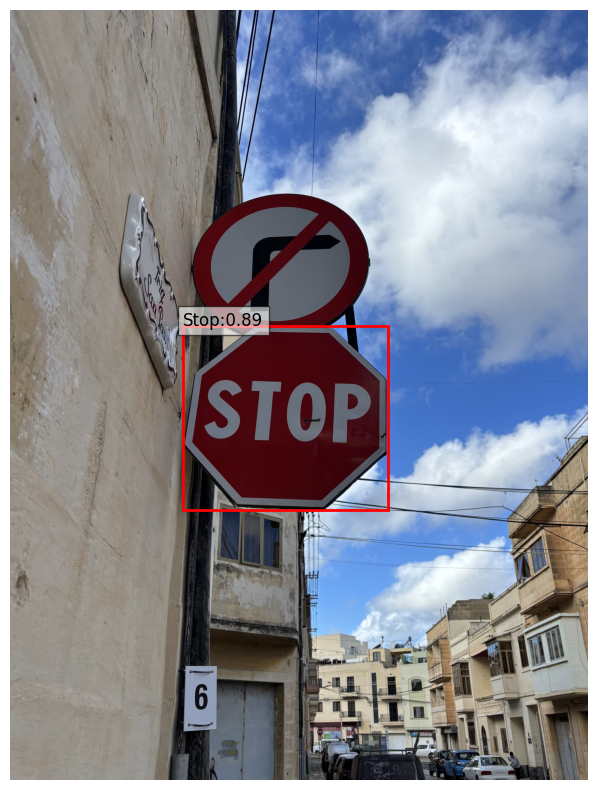

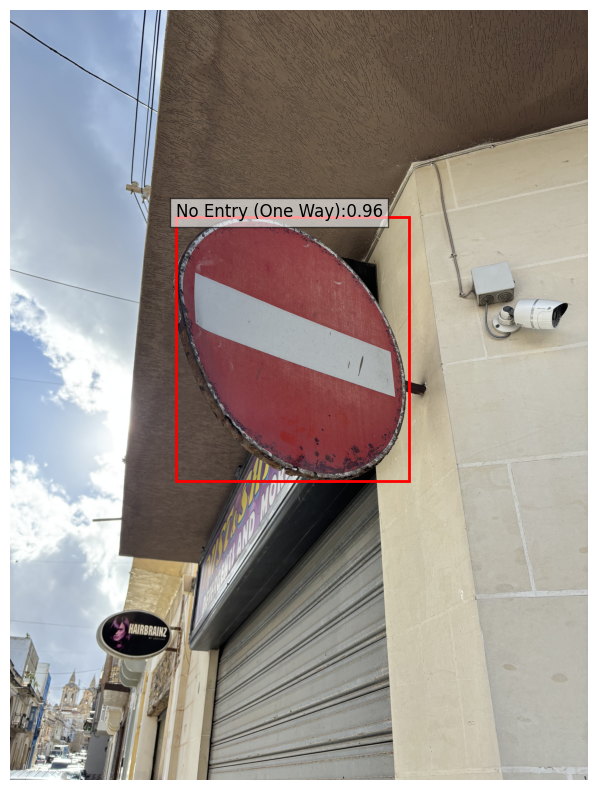

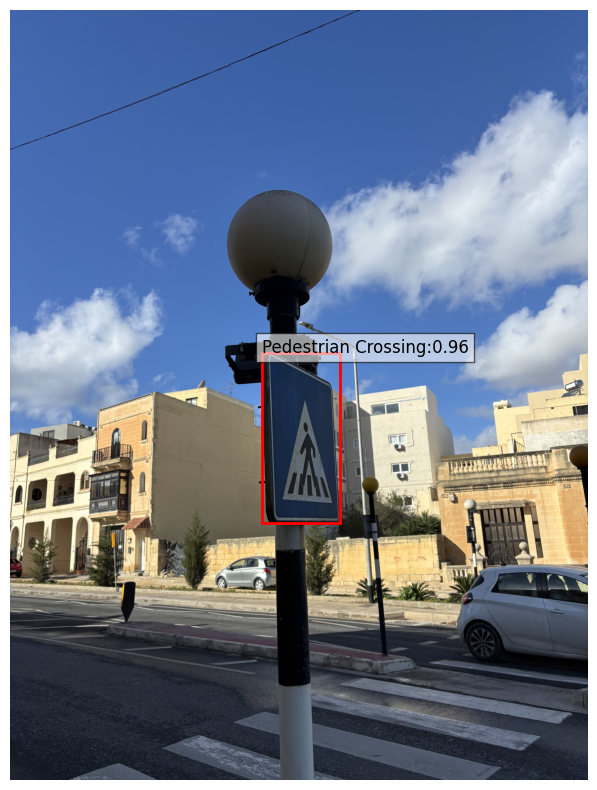

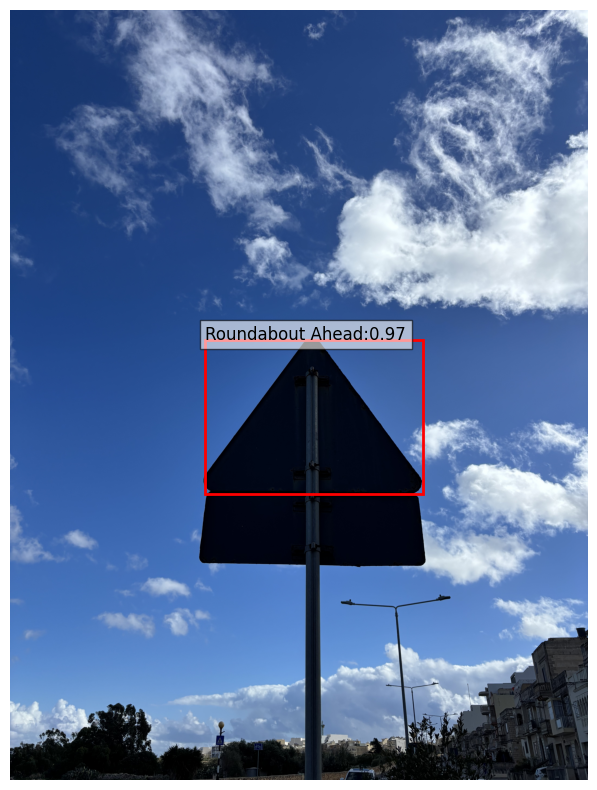

In [17]:
ims = [r"coco_set\coco_sign_shape\test\IMG_1506.jpg",
       r"coco_set\coco_sign_shape\test\IMG_1517.jpg",
       r"coco_set\coco_sign_shape\test\IMG_1532.jpg",
       r"coco_set\coco_sign_shape\test\IMG_1550.jpg"]

# Examples:
for im in ims:
    plot_rfdetr_predictions(model, im, score_thresh=0.5, classidx_to_name=classidx_to_name)


## Plotting Set Distribution

Summary:


,split,images_in_json,annotations_in_json,image_files_in_folder
0,test,89,97,89
1,train,467,531,467
2,valid,89,96,89



Per-class distribution (first rows):


,split,category_id,category,annotations
0,test,0,Blind-Spot Mirror (Convex),10
1,test,1,No Entry (One Way),30
2,test,2,No Through Road (T-Sign),7
3,test,3,Pedestrian Crossing,19
4,test,4,Roundabout Ahead,7
5,test,5,Stop,24
6,train,0,Blind-Spot Mirror (Convex),62
7,train,1,No Entry (One Way),130
8,train,2,No Through Road (T-Sign),36
9,train,3,Pedestrian Crossing,123


<Figure size 1200x600 with 0 Axes>

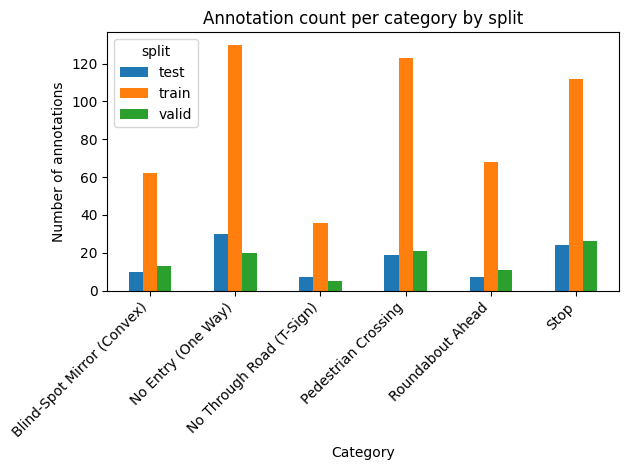

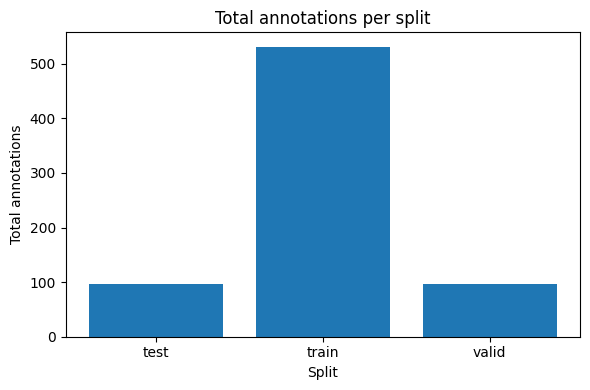

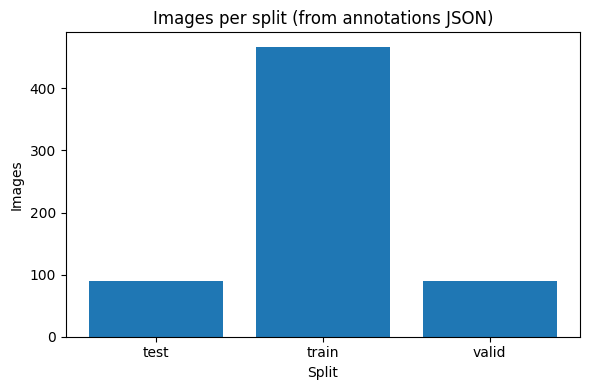

In [10]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt


def _load_json(p: Path) -> dict:
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)


def _split_name_from_ann_path(ann_path: Path) -> str:
    # expects .../<split>/_annotations.json
    return ann_path.parent.name


def _count_images_in_dir(img_dir: Path) -> int:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
    return sum(1 for p in img_dir.iterdir() if p.is_file() and p.suffix.lower() in exts)


def build_distributions(annotation_paths, image_paths):
    # ---- Load all coco files, build unified category id->name map ----
    coco_by_split = {}
    cat_id_to_name = {}

    for ann_path in annotation_paths:
        ann_path = Path(ann_path)
        split = _split_name_from_ann_path(ann_path)
        coco = _load_json(ann_path)
        coco_by_split[split] = coco

        for c in coco.get("categories", []):
            cat_id_to_name[int(c["id"])] = c.get("name", str(c["id"]))

    all_cat_ids = sorted(cat_id_to_name.keys())

    # ---- Build tidy DF: rows = (split, category_id, category, annotations) ----
    rows = []
    for split, coco in coco_by_split.items():
        counts = Counter(int(a["category_id"]) for a in coco.get("annotations", []))

        # include zeros for missing classes to make plotting consistent
        for cid in all_cat_ids:
            rows.append(
                {
                    "split": split,
                    "category_id": cid,
                    "category": cat_id_to_name.get(cid, str(cid)),
                    "annotations": int(counts.get(cid, 0)),
                }
            )

    dist_df = pd.DataFrame(rows).sort_values(["split", "category_id"]).reset_index(drop=True)

    # ---- Summary DF: images + annotations per split ----
    summary_rows = []
    img_dir_by_split = {Path(p).name: Path(p) for p in image_paths}

    for split, coco in coco_by_split.items():
        num_images_json = len(coco.get("images", []))
        num_annotations_json = len(coco.get("annotations", []))

        num_images_dir = None
        if split in img_dir_by_split and img_dir_by_split[split].exists():
            num_images_dir = _count_images_in_dir(img_dir_by_split[split])

        summary_rows.append(
            {
                "split": split,
                "images_in_json": num_images_json,
                "annotations_in_json": num_annotations_json,
                "image_files_in_folder": num_images_dir,
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values("split").reset_index(drop=True)
    return dist_df, summary_df


def plot_distributions(dist_df, summary_df):
    # Plot 1: grouped bars (annotations per category by split)
    pivot = dist_df.pivot_table(index="category", columns="split", values="annotations", aggfunc="sum", fill_value=0)

    plt.figure(figsize=(12, 6))
    pivot.plot(kind="bar")
    plt.title("Annotation count per category by split")
    plt.xlabel("Category")
    plt.ylabel("Number of annotations")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Plot 2: total annotations per split
    totals = summary_df.set_index("split")["annotations_in_json"]
    plt.figure(figsize=(6, 4))
    plt.bar(totals.index.astype(str), totals.values)
    plt.title("Total annotations per split")
    plt.xlabel("Split")
    plt.ylabel("Total annotations")
    plt.tight_layout()
    plt.show()

    # Plot 3: images per split (from JSON, and optionally folder count)
    imgs_json = summary_df.set_index("split")["images_in_json"]
    plt.figure(figsize=(6, 4))
    plt.bar(imgs_json.index.astype(str), imgs_json.values)
    plt.title("Images per split (from annotations JSON)")
    plt.xlabel("Split")
    plt.ylabel("Images")
    plt.tight_layout()
    plt.show()


# ---- Run ----
dist_df, summary_df = build_distributions(annotation_paths, image_paths)

print("Summary:")
display(summary_df)

print("\nPer-class distribution (first rows):")
display(dist_df.head(20))

plot_distributions(dist_df, summary_df)
